Objective : To build a Convolutional Autoencoder(CAE) that compresses facial images into lower-dimentional latent representation and reconstructs them with minimal loss of information

Purpose: A Convolutional AutoEncoder(CAE) is a unsupervised learning model used for: Image Compression Image Reconstruction Feature Extraction Dimensionally Reduction. The encoder learns a compressed representation(:atent space), while the decoder reconstructs the original image from this compressed representation.

In [ ]:
#importing required libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [ ]:
# Loading dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:

source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for img in images:
  shutil.copy(
      os.path.join(source_folder, img),
      destination_folder
  )
print("Copied", len(images), "images")

Copied 5000 images


In [ ]:
# data preprocession
Image_size = (64,64)
# for accuracy using 32, we can user 64, 128, 256
batch_size = 32

In [ ]:
# Greyscalling
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split = 0.2
)

In [ ]:
# Load dataset
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size = Image_size,
    batch_size = batch_size,
    class_mode = "input",
    subset = "training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size = Image_size,
    batch_size = batch_size,
    class_mode = "input",
    subset = "training"
)

Found 4000 images belonging to 1 classes.


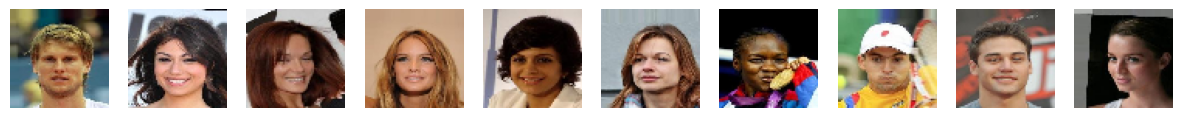

In [ ]:
# Display sample images
images,_=next(train_generator)
plt.figure(figsize=(15,6))
for i in range(10):
  plt.subplot(1,10,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [ ]:
# Build Convolutional Autoencoder
#Encoder
input_img = Input(shape=(64,64,3))
x = Conv2D(
    32,
    (3,3),
    activation = 'relu',
    padding = 'same'
)(input_img)
x = MaxPooling2D(
    (2,2), padding='same'
)(x)
x = Conv2D(
    64, (3,3), activation='relu',
    padding='same'
)(x)
encoded = MaxPooling2D(
    (2,2), padding='same'
)(x)

In [ ]:
# Decoder
x = Conv2D(
    64, (3,3), activation='relu', padding='same'
)(encoded)

x = UpSampling2D((2,2))(x)
x = Conv2D(
    32,(3,3), activation='relu', padding='same'
)(x)

x = UpSampling2D((2,2))(x)
decoded = Conv2D(
    3,(3,3), activation='sigmoid', padding='same'
)(x)

In [ ]:
# Create Model
autoencoder = Model(
    input_img, decoded
)

In [ ]:
# Compile Model
autoencoder.compile(
    optimizer = 'adam', loss = 'binary_crossentropy'
)

In [ ]:
# Model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model
history = autoencoder.fit(
    train_generator,
    validation_data = validation_generator,
    epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 0.5265 - val_loss: 0.4969
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.4932 - val_loss: 0.4900
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.4881 - val_loss: 0.4865
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.4868 - val_loss: 0.4855
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.4853 - val_loss: 0.4846
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.4842 - val_loss: 0.4839
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.4837 - val_loss: 0.4830
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.4834 - val_loss: 0.4826
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 0.4827 - val_loss: 0.4823
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.4824 - val_loss: 0.4820


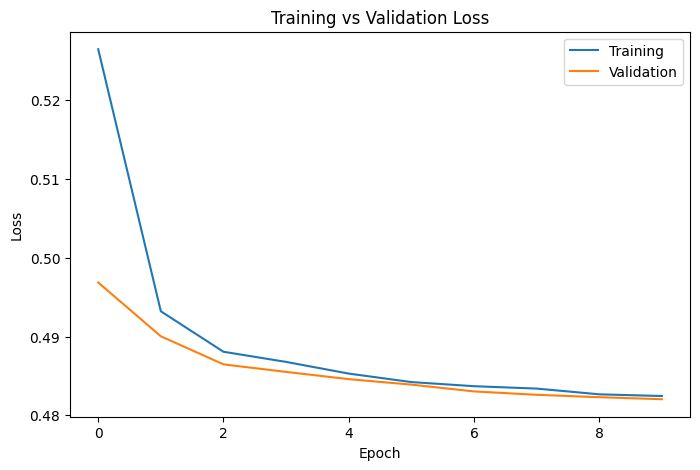

In [ ]:
# Plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Training", "Validation"])
plt.show()

In [ ]:
# Evaluate Model
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss: ", loss)


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4820
Validation Loss:  0.4820375442504883


In [ ]:
# Reconstruct Images
images,_= next(validation_generator)
reconstructed = autoencoder.predict(images)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step


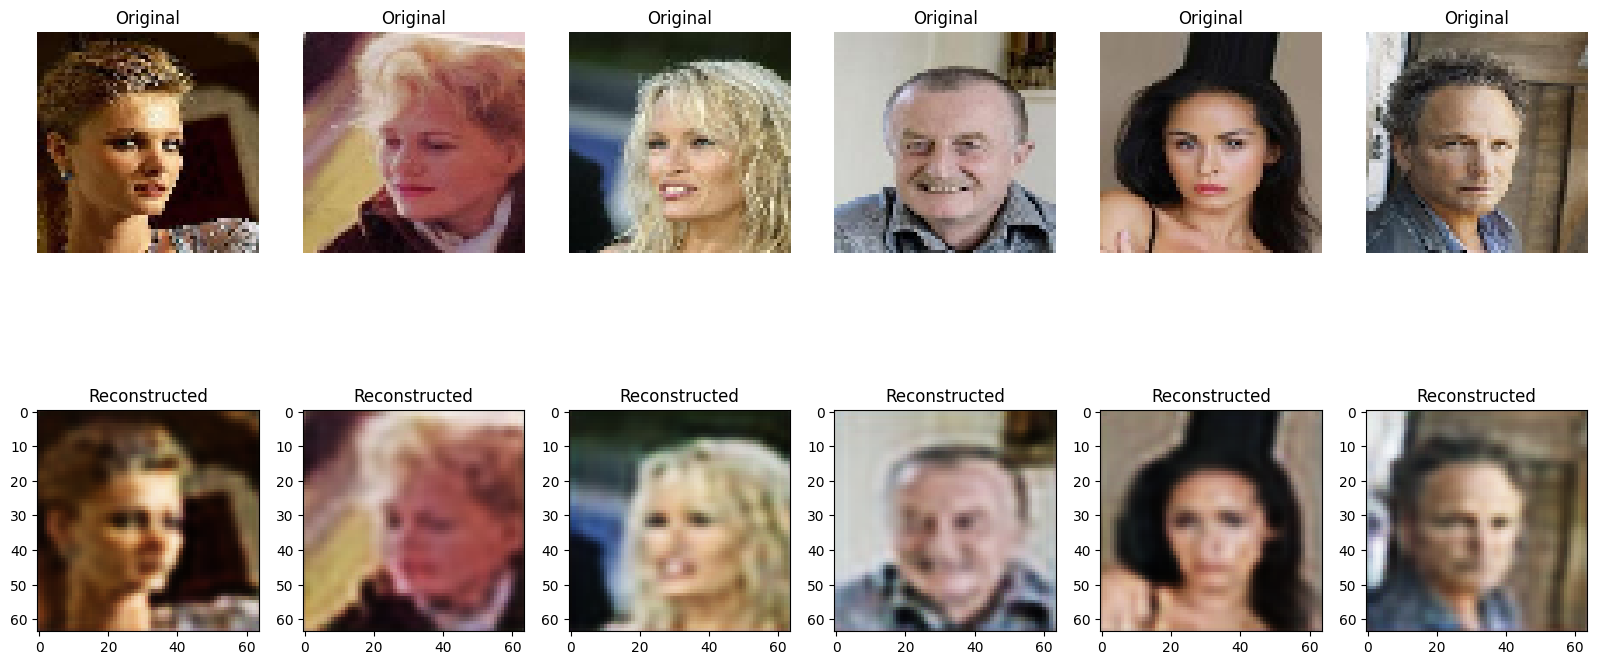

In [ ]:
# Display results
n = 6
plt.figure(figsize=(20,9))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+n+1)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")
